Cell 1 — Import & Setup

In [1]:
import os
import sys
from pathlib import Path

# Đảm bảo thư mục làm việc luôn là thư mục gốc dự án
if Path(os.getcwd()).name == "notebooks":
    os.chdir("..")
    
if str(os.getcwd()) not in sys.path:
    sys.path.append(str(os.getcwd()))

import torch

from src.utils import (load_config, set_seed,
                       get_device, ensure_dirs,
                       save_loss_curve, save_accuracy_curve)
from src.dataset import get_dataloaders
from src.model   import build_model, count_parameters
from src.train   import train

# ── Load config ───────────────────────────────────────────────── #
cfg    = load_config("config.yaml") 
set_seed(cfg["training"]["seed"])
device = get_device()
ensure_dirs(cfg)

# [VÁ LỖI TREO MÁY TRÊN WINDOWS]: Ép num_workers về 0
cfg['training']['num_workers'] = 0

print(f"✅ Setup hoàn tất. Thư mục hoạt động: {os.getcwd()}")
print("\n[Config]")
print(f"  Architecture  : {cfg['model']['architecture']}")
print(f"  Pretrained    : {cfg['model']['pretrained']}")
print(f"  Epochs        : {cfg['training']['epochs']}")
print(f"  Warmup epochs : {cfg['model'].get('warmup_epochs', 0)}")
print(f"  Batch size    : {cfg['training']['batch_size']}")
print(f"  Learning rate : {cfg['training']['learning_rate']}")
print(f"  Seed          : {cfg['training']['seed']}")

[Device] Đang dùng: cpu
✅ Setup hoàn tất. Thư mục hoạt động: c:\Users\Thang\source\repos\brain-tumor-classification

[Config]
  Architecture  : resnet18
  Pretrained    : True
  Epochs        : 20
  Warmup epochs : 3
  Batch size    : 32
  Learning rate : 0.001
  Seed          : 42


Cell 2 — Kiểm tra GPU

In [2]:
print("\n[Hardware]")
print(f"  Device : {device}")

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    mem_total = gpu.total_memory / 1024**3
    mem_used  = torch.cuda.memory_allocated(0) / 1024**3
    print(f"  GPU    : {gpu.name}")
    print(f"  VRAM   : {mem_total:.1f} GB total | {mem_used:.2f} GB used")
else:
    print("  ⚠️  Không có GPU — training sẽ chậm hơn đáng kể")
    print("  💡 Gợi ý: Dùng Google Colab (Runtime → Change runtime → T4 GPU)")


[Hardware]
  Device : cpu
  ⚠️  Không có GPU — training sẽ chậm hơn đáng kể
  💡 Gợi ý: Dùng Google Colab (Runtime → Change runtime → T4 GPU)


Cell 3 — Load Data

In [3]:
print("\n[Data] Đang load dataset...")

train_loader, val_loader, test_loader, \
class_to_idx, idx_to_class = get_dataloaders(cfg)

# Kiểm tra 1 batch
images, labels = next(iter(train_loader))
print(f"\n[Batch kiểm tra]")
print(f"  Images shape : {images.shape}")     # [B, 3, 224, 224]
print(f"  Labels shape : {labels.shape}")     # [B]
print(f"  Label values : {labels.tolist()}")
print(f"  Class map    : {class_to_idx}")

# Kiểm tra memory ảnh
mem_mb = images.element_size() * images.nelement() / 1024**2
print(f"  Batch memory : {mem_mb:.2f} MB")


[Data] Đang load dataset...
[Dataset] Quét thư mục Training...
  [glioma] 1321 ảnh
  [meningioma] 1339 ảnh
  [notumor] 1595 ảnh
  [pituitary] 1457 ảnh
  → Tổng: 5712 ảnh

[Phân bố dữ liệu]
  glioma               1321 ảnh
  meningioma           1339 ảnh
  notumor              1595 ảnh
  pituitary            1457 ảnh

[Dataset] Quét thư mục Testing...
  [glioma] 300 ảnh
  [meningioma] 306 ảnh
  [notumor] 405 ảnh
  [pituitary] 300 ảnh
  → Tổng: 1311 ảnh

[Split] Train: 4855 | Val: 857 | Test: 1311

[Batch kiểm tra]
  Images shape : torch.Size([32, 3, 224, 224])
  Labels shape : torch.Size([32])
  Label values : [0, 2, 0, 2, 2, 1, 2, 2, 2, 3, 3, 1, 0, 3, 1, 0, 2, 0, 2, 3, 2, 2, 3, 0, 1, 0, 3, 2, 2, 2, 3, 2]
  Class map    : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}
  Batch memory : 18.38 MB


Cell 4 — Xem ảnh trong batch (kiểm tra augmentation)

C:\Users\Thang\AppData\Local\Temp\ipykernel_56936\2615850924.py:26: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Thang\AppData\Local\Temp\ipykernel_56936\2615850924.py:28: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  plt.savefig("outputs/figures/augmented_batch.png",
c:\Users\Thang\source\repos\brain-tumor-classification\env_mri\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128444 (\N{FRAME WITH PICTURE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


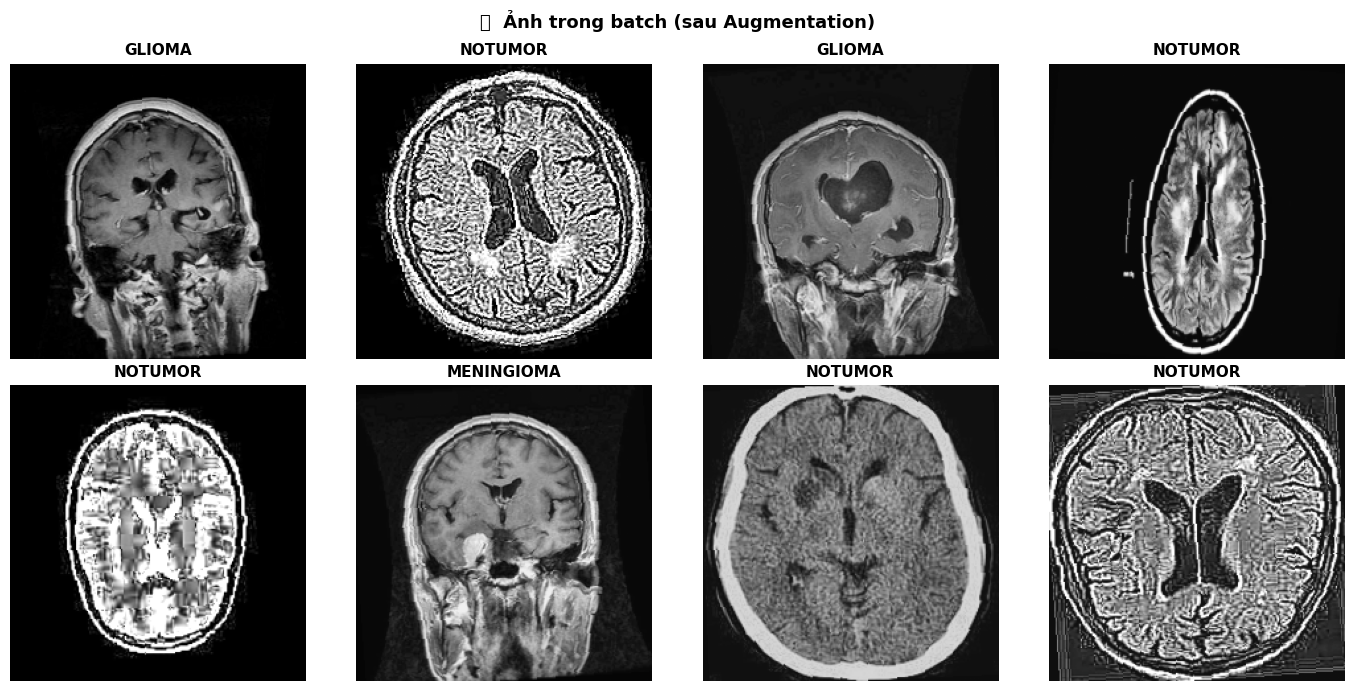

✅ Augmentation trông hợp lý — sẵn sàng training


In [4]:
import matplotlib.pyplot as plt
import numpy as np

def denormalize(tensor):
    """Đảo ngược normalize để hiển thị ảnh"""
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

n_show = min(8, len(images))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(n_show):
    img  = denormalize(images[i]).permute(1, 2, 0).numpy()
    cls  = idx_to_class[labels[i].item()]
    axes[i].imshow(img)
    axes[i].set_title(cls.upper(), fontsize=11, fontweight="bold")
    axes[i].axis("off")

for j in range(n_show, len(axes)):
    axes[j].axis("off")

plt.suptitle("🖼️  Ảnh trong batch (sau Augmentation)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
# Bỏ ../, lưu dựa vào cấu hình gốc
plt.savefig("outputs/figures/augmented_batch.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Augmentation trông hợp lý — sẵn sàng training")

Cell 5 — Khởi tạo Model

In [5]:
print("\n[Model] Đang khởi tạo...")
model = build_model(cfg).to(device)
count_parameters(model)

# Thử forward pass để đảm bảo không lỗi
dummy  = torch.randn(2, 3, 224, 224).to(device)
with torch.no_grad():
    out = model(dummy)
print(f"[Model] Forward pass OK — output shape: {out.shape}")
del dummy
torch.cuda.empty_cache() if torch.cuda.is_available() else None


[Model] Đang khởi tạo...
[Model] Kiến trúc : resnet18
[Model] Pretrained : True
[Model] Num classes: 4

[Params] Tổng      :   11,441,220
[Params] Trainable :   11,441,220
[Params] Frozen    :            0

[Model] Forward pass OK — output shape: torch.Size([2, 4])


Cell 6 — Training

In [ ]:
# ── Chạy training ─────────────────────────────────────────────── #
# Toàn bộ logic nằm trong src/train.py:
#   Giai đoạn 1 (warmup_epochs đầu) : đóng băng backbone, train head
#   Giai đoạn 2 (còn lại)           : mở băng N layer, fine-tune
#   Best model lưu tự động theo val_loss
#   Early stopping nếu không cải thiện sau 7 epochs

history = train(model, train_loader, val_loader, cfg, device)

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\Thang\_netrc.
wandb: Currently logged in as: thangviet (thangviet-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[Freeze] Chỉ train classifier — 264,708 params
[Optimizer] Adam — backbone lr=0.0001 | head lr=0.001

  BẮT ĐẦU TRAINING — 20 epochs | warmup: 3

Epoch [01/20] — warm-up
    Batch [20/152] Loss: 0.7433 | Acc: 81.2%
    Batch [40/152] Loss: 0.6344 | Acc: 84.4%
    Batch [60/152] Loss: 1.0063 | Acc: 75.0%
    Batch [80/152] Loss: 0.7925 | Acc: 78.1%
    Batch [100/152] Loss: 0.5824 | Acc: 87.5%
    Batch [120/152] Loss: 0.6286 | Acc: 81.2%
    Batch [140/152] Loss: 0.7193 | Acc: 81.2%
  Train — Loss: 0.7866 | Acc: 77.16%
  Val   — Loss: 0.6506   | Acc: 85.30%
  LR: 0.001000 | Time: 269.9s
  ✅ Lưu best model — val_loss: 0.6506

Epoch [02/20] — warm-up


Cell 7 — Vẽ biểu đồ Loss & Accuracy

In [ ]:
from pathlib import Path
FIG_DIR = Path("outputs/figures")

# Loss curve
save_loss_curve(
    history["train_loss"],
    history["val_loss"],
    save_path=str(FIG_DIR / "loss_curve.png"),
)

# Accuracy curve
save_accuracy_curve(
    history["train_acc"],
    history["val_acc"],
    save_path=str(FIG_DIR / "accuracy_curve.png"),
)

# ── Hiển thị cả 2 biểu đồ cạnh nhau ─────────────────────────── #
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ran = range(1, len(history["train_loss"]) + 1)

# Loss
axes[0].plot(epochs_ran, history["train_loss"],
             "o-", color="#3498db", label="Train Loss", linewidth=2)
axes[0].plot(epochs_ran, history["val_loss"],
             "s-", color="#e74c3c", label="Val Loss",   linewidth=2)
best_epoch = int(np.argmin(history["val_loss"])) + 1
axes[0].axvline(best_epoch, color="gray", linestyle="--", alpha=0.7,
                label=f"Best epoch: {best_epoch}")
axes[0].set_title("Loss Curve", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs_ran, history["train_acc"],
             "o-", color="#3498db", label="Train Acc", linewidth=2)
axes[1].plot(epochs_ran, history["val_acc"],
             "s-", color="#e74c3c", label="Val Acc",   linewidth=2)
axes[1].axvline(best_epoch, color="gray", linestyle="--", alpha=0.7,
                label=f"Best epoch: {best_epoch}")
axes[1].set_title("Accuracy Curve", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("📈 Training History", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "training_history.png", dpi=150, bbox_inches="tight")
plt.show()

Cell 8 — Phân tích training log (CSV)

In [ ]:
import pandas as pd

log_path = "outputs/logs/train_log.csv"
df       = pd.read_csv(log_path)

print(df.to_string(index=False))

# ── Thống kê nhanh ────────────────────────────────────────────── #
best_row = df.loc[df["val_loss"].idxmin()]
print("\n" + "="*50)
print("  📌 Best Checkpoint")
print("="*50)
print(f"  Epoch     : {int(best_row['epoch'])}")
print(f"  Phase     : {best_row['phase']}")
print(f"  Val Loss  : {best_row['val_loss']:.5f}")
print(f"  Val Acc   : {best_row['val_acc']:.3f}%")
print(f"  Train Acc : {best_row['train_acc']:.3f}%")
print(f"  LR        : {best_row['lr']}")

# ── Gap train/val accuracy → dấu hiệu overfit ─────────────────── #
df["gap"] = df["train_acc"] - df["val_acc"]
max_gap   = df["gap"].max()
print(f"\n  Max gap (Train - Val Acc) : {max_gap:.2f}%")
if max_gap > 10:
    print("  ⚠️  Gap lớn — có dấu hiệu Overfitting")
    print("     Gợi ý: tăng Dropout, thêm augmentation, giảm epochs")
else:
    print("  ✅ Gap nhỏ — mô hình tổng quát hoá tốt")

Cell 9 — Tổng kết & Kiểm tra file đầu ra

In [ ]:
import os

print("=" * 55)
print("  ✅ TRAINING HOÀN TẤT")
print("=" * 55)

# Kiểm tra best_model.pth
model_path = cfg["paths"]["best_model"]
if os.path.exists(model_path): 
    size_mb = os.path.getsize(model_path) / 1024**2 
    ckpt    = torch.load(model_path, map_location="cpu") 
# ... [Các đoạn in thông số giữ nguyên] ...

# Liệt kê file outputs
print(f"\n  📊 Figures:")
for f in sorted(Path("outputs/figures").glob("*.png")): 
    print(f"     {f.name}")

print(f"\n  📝 Logs:")
for f in sorted(Path("outputs/logs").glob("*")): 
    print(f"     {f.name}")

print("\n" + "=" * 55)
print("  ➡️  Tiếp theo: chạy 03_evaluation.ipynb")
print("=" * 55)